In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# !pip uninstall -y numpy scipy scikit-learn tensorflow mediapipe

# !pip install numpy==1.26.4
# !pip install scipy==1.11.4
# !pip install scikit-learn==1.3.2
# !pip install tensorflow==2.18.0
!pip install mediapipe==0.10.20

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 67.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but yo

In [2]:
import cv2
import mediapipe as mp
import numpy as np
import os
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split

2026-04-14 07:17:42.671451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776151062.699422     293 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776151062.707490     293 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
DATASET_PATH = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train"

In [4]:
labels = sorted(os.listdir(DATASET_PATH))
print(labels)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [5]:
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776151080.538584     367 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776151080.600706     367 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [9]:
def extract_keypoints(image):

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)

    keypoints = np.zeros(63)

    if results.multi_hand_landmarks:

        hand = results.multi_hand_landmarks[0]

        #wrist (landmark 0) as reference point
        base_x = hand.landmark[0].x
        base_y = hand.landmark[0].y
        base_z = hand.landmark[0].z

        for i, lm in enumerate(hand.landmark):

            keypoints[i*3]   = lm.x - base_x
            keypoints[i*3+1] = lm.y - base_y
            keypoints[i*3+2] = lm.z - base_z

        #normalization for stability
        max_val = np.max(np.abs(keypoints))

        if max_val != 0:
            keypoints = keypoints / max_val

    return keypoints

In [10]:
labels = sorted(os.listdir(DATASET_PATH))

X = []
y = []

for label in labels:

    folder = os.path.join(DATASET_PATH, label)

    for img_name in tqdm(os.listdir(folder), desc=label):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        keypoints = extract_keypoints(img)

        X.append(keypoints)
        y.append(labels.index(label))

X = np.array(X)
y = np.array(y)

space: 100%|██████████| 3000/3000 [02:18<00:00, 21.70it/s]


In [11]:
print("Dataset shape:", X.shape)

Dataset shape: (87000, 63)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(63,)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(len(labels), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-14 08:38:43.277077: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,333 (71.61 KB)

 Trainable params: 18,333 (71.61 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5145 - loss: 1.7254 - val_accuracy: 0.7457 - val_loss: 0.9564
Epoch 2/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7302 - loss: 1.0016 - val_accuracy: 0.7525 - val_loss: 0.9071
Epoch 3/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7424 - loss: 0.9480 - val_accuracy: 0.7548 - val_loss: 0.8938
Epoch 4/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7459 - loss: 0.9363 - val_accuracy: 0.7553 - val_loss: 0.8921
Epoch 5/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7484 - loss: 0.9212 - val_accuracy: 0.7597 - val_loss: 0.8792
Epoch 6/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7487 - loss: 0.9230 - val_accuracy: 0.7561 - val_loss: 0.8835
Epoch 7/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7529 - loss: 0.9106 - val_accuracy: 0.7609 - val_loss: 0.8729
Epoch 8/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7518 - loss: 0.9088 - 

In [15]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7692 - loss: 0.8408
Test Accuracy: 0.7631609439849854


In [16]:
model.save("asl_model.keras")

In [17]:
np.save("labels.npy", labels)

In [18]:
from IPython.display import FileLink

FileLink("labels.npy")

/kaggle/working/labels.npy

In [19]:
FileLink("asl_model.keras")

/kaggle/working/asl_model.keras

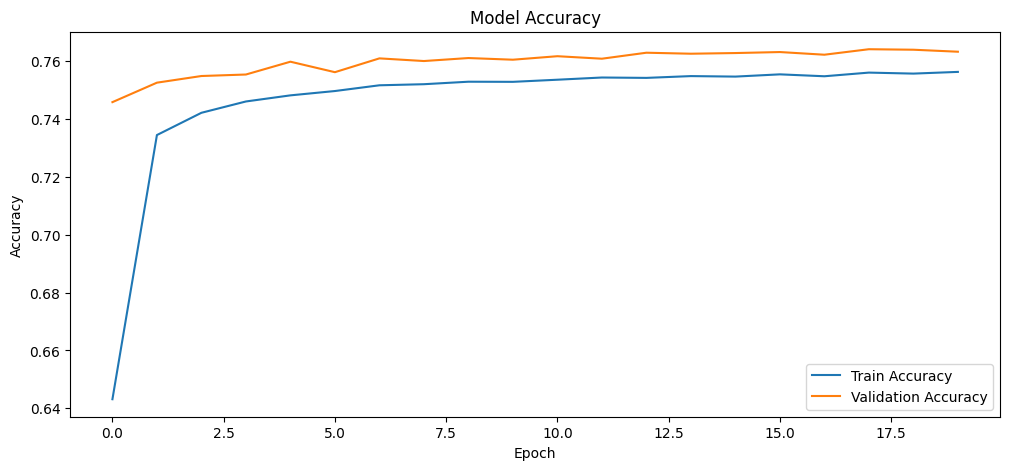

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

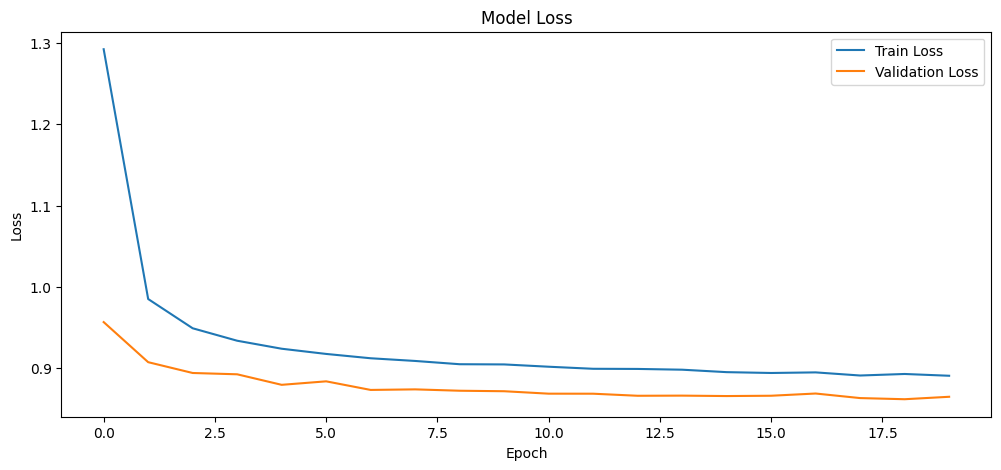

In [22]:
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
              precision    recall  f1-score   support

           A       0.97      0.74      0.84       584
           B       1.00      0.72      0.84       574
           C       1.00      0.66      0.79       617
           D       1.00      0.82      0.90       589
           E       1.00      0.77      0.87       602
           F       1.00      0.96      0.98       580
           G       1.00      0.81      0.90       585
           H       1.00      0.82      0.90       587
           I       0.99      0.79      0.88       599
           J       1.00      0.87      0.93       598
           K       0.99      0.90      0.94       610
           L       1.00      0.86      0.92       609
           M       0.94      0.48      0.64       641
           N       0.93      0.40      0.56       626
           O       0.99      0.76      0.86       587
           P       1.00      0.68      0.81       568
           Q     

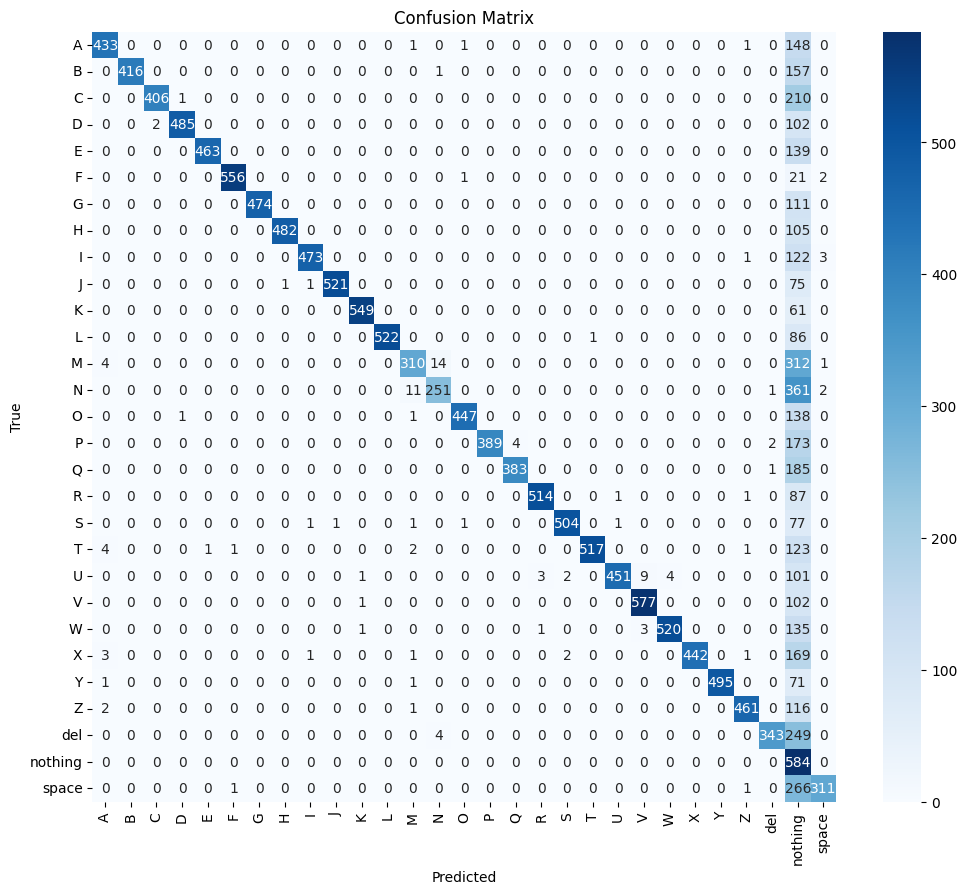

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [24]:
TEST_PATH = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

predicted_letters = []

img_names = sorted(os.listdir(TEST_PATH))
for img_name in img_names:
    img_path = os.path.join(TEST_PATH, img_name)

    img = cv2.imread(img_path)

    if img is None:
        continue

    keypoints = extract_keypoints(img)

    input_data = np.expand_dims(keypoints, axis=0)

    pred = model.predict(input_data, verbose=0)[0]

    letter = labels[np.argmax(pred)]

    predicted_letters.append(letter)

sentence_pred = "".join(predicted_letters)

print("Predicted letters:", predicted_letters)
print("Predicted sentence:", sentence_pred)

Predicted letters: ['nothing', 'B', 'nothing', 'nothing', 'nothing', 'F', 'G', 'nothing', 'I', 'J', 'K', 'L', 'nothing', 'nothing', 'nothing', 'P', 'Q', 'nothing', 'S', 'T', 'nothing', 'nothing', 'W', 'nothing', 'Y', 'nothing', 'nothing', 'space']
Predicted sentence: nothingBnothingnothingnothingFGnothingIJKLnothingnothingnothingPQnothingSTnothingnothingWnothingYnothingnothingspace


In [25]:
from collections import deque, Counter

TEST_PATH = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

predicted_letters = []

img_names = sorted(os.listdir(TEST_PATH))

buffer = deque(maxlen=5)

last_letter = ""
confidence_threshold = 0.80

for img_name in img_names:

    img_path = os.path.join(TEST_PATH, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    keypoints = extract_keypoints(img)

    input_data = np.expand_dims(keypoints, axis=0)

    pred = model.predict(input_data, verbose=0)[0]

    idx = np.argmax(pred)
    confidence = np.max(pred)

    letter = labels[idx]

    if confidence < confidence_threshold:
        continue

    if letter == "nothing":
        continue

    if letter == "space":
        letter = " "

    buffer.append(letter)
    letter = Counter(buffer).most_common(1)[0][0]

    if letter == last_letter:
        continue

    predicted_letters.append(letter)
    last_letter = letter

sentence_pred = "".join(predicted_letters)

print("Predicted letters:", predicted_letters)
print("Predicted sentence:", sentence_pred)

Predicted letters: ['B', 'F', 'G', 'I', 'J', 'K', 'L', 'P', 'Q', 'S']
Predicted sentence: BFGIJKLPQS
